### Amazon-liked Supply Chain Analytics: Profit Optimization & Delivery Performence Analysis

In [1]:
import pandas as pd
import numpy as np

#1. Load the Dataset
try:
    df = pd.read_csv('supply_chain_dataset.csv' , encoding='ISO-8859-1')
    print("✅ Filed Loaded Succesfully!")
except FileNotFoundError:
    print("❌Error: File Not Found. Please check the file name.")

#2. Basic Inspection
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())


#3. Check for Missing Values
print("\n---- Missing Values Count ---")
print(df.isnull().sum())

#4. Filter relevant columns for your project
columns_to_keep = [
    'Type' , 'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Benefit per order', 'Sales per customer', 'Delivery Status', 
    'Late_delivery_risk', 'Category Name', 'Customer City', 
    'Order Profit Per Order', 'Shipping Mode'
]

df_clean = df[columns_to_keep]

print("\n--- Cleaned Data Sample ---")
print(df_clean.head())

✅ Filed Loaded Succesfully!

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177748 entries, 0 to 177747
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           177748 non-null  object 
 1   Days for shipping (real)       177748 non-null  int64  
 2   Days for shipment (scheduled)  177748 non-null  int64  
 3   Benefit per order              177748 non-null  float64
 4   Sales per customer             177748 non-null  float64
 5   Delivery Status                177748 non-null  object 
 6   Late_delivery_risk             177748 non-null  int64  
 7   Category Name                  177748 non-null  object 
 8   Customer City                  177748 non-null  object 
 9   Order Profit Per Order         177748 non-null  float64
 10  Shipping Mode                  177748 non-null  object 
 11  Delay                          177748 non

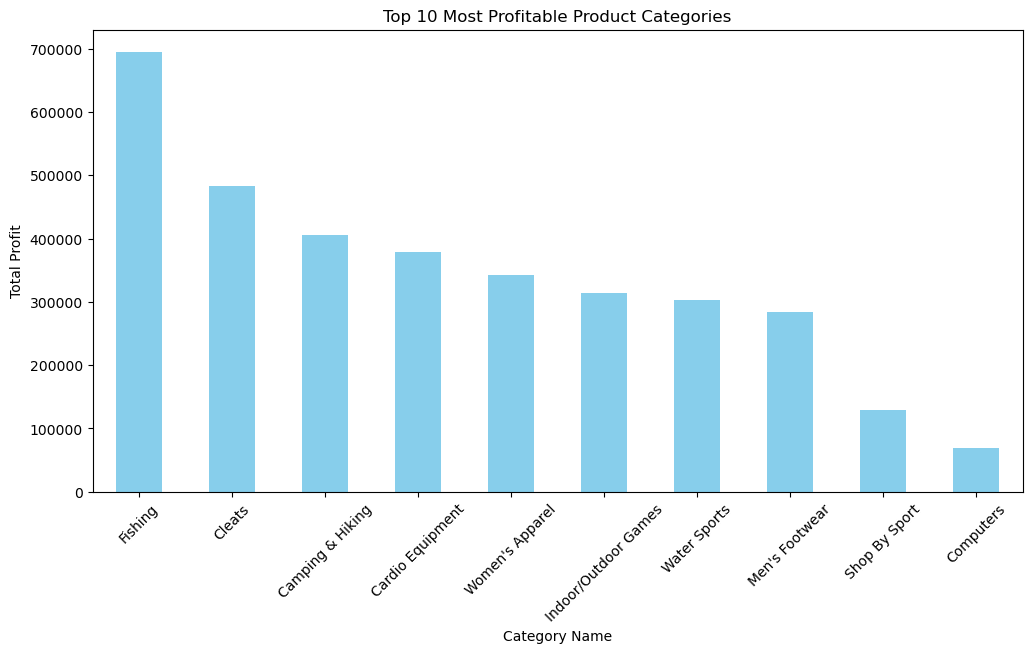

Top 5 Profitable Categories:
Category Name
Fishing             695334.087123
Cleats              482579.689755
Camping & Hiking    405471.838177
Cardio Equipment    379492.868503
Women's Apparel     342501.969577
Name: Order Profit Per Order, dtype: float64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Handling Missing Values (Data Science Skill)
# Filling missing prices with the mean (average) or dropping them
df_clean = df_clean.dropna(subset=['Order Profit Per Order'])

# 2. Analysis: Grouping data by Category (Analysis Skill)
category_analysis = df_clean.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10)

# 3. Visualization: Plotting the Top 10 Profitable Categories (Visualization Skill)
plt.figure(figsize=(12,6))
category_analysis.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Profitable Product Categories')
plt.xlabel('Category Name')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

# 4. Display the top categories numerically
print("Top 5 Profitable Categories:")
print(category_analysis.head(5))

In [7]:
from scipy.optimize import linprog

# 1. Define the Profit per unit (Approximated from your chart)
# We want to MAXIMIZE this, so we use negative values for the solver
profit_per_unit = [-150, -100, -80] # Fishing, Cleats, Camping

# 2. Constraints (LHS)
# Budget constraint: $200 per Fishing item, $120 per Cleat, $100 per Camping item
# Space constraint: 1 unit of each
A = [[200, 120, 100], 
     [1, 1, 1]]

# 3. Constraints (RHS)
b = [50000,  # Total Budget
     1000]   # Total Storage Space

# 4. Bounds (Min 0 units, Max 500 for any single category to stay balanced)
x_bounds = (0, 500)

# 5. Solve
res = linprog(profit_per_unit, A_ub=A, b_ub=b, bounds=[x_bounds, x_bounds, x_bounds], method='highs')

# 6. Results
print("--- Optimization Results ---")
print(f"Optimal Units for Fishing: {round(res.x[0])}")
print(f"Optimal Units for Cleats: {round(res.x[1])}")
print(f"Optimal Units for Camping: {round(res.x[2])}")
print(f"Total Predicted Profit: ${round(-res.fun)}")

--- Optimization Results ---
Optimal Units for Fishing: 0
Optimal Units for Cleats: 417
Optimal Units for Camping: 0
Total Predicted Profit: $41667


In [4]:
# Delay
df['Delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# Late Delivery
df['Is Late'] = df['Delay'].apply(lambda x: 1 if x > 0 else 0)

# Profit Margin
df['Profit Margin'] = df['Order Profit Per Order'] / df['Sales per customer']

print("\n--- New Features ---")
print(df[['Delay', 'Is Late', 'Profit Margin']].head())


--- New Features ---
   Delay  Is Late  Profit Margin
0     -1        0       0.290014
1      1        1      -0.800006
2      0        0      -0.800013
3     -1        0       0.074998
4     -2        0       0.449992


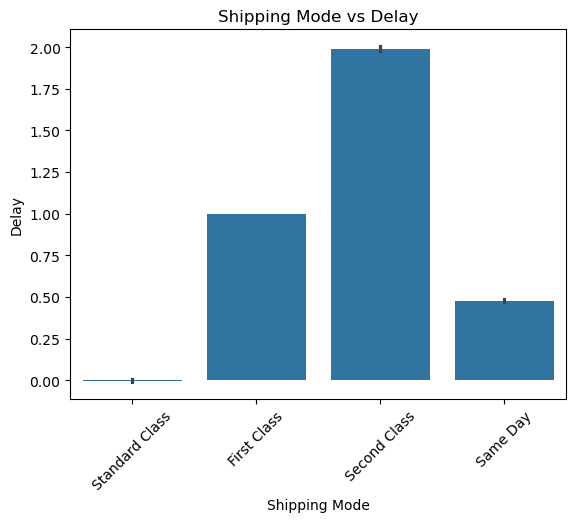

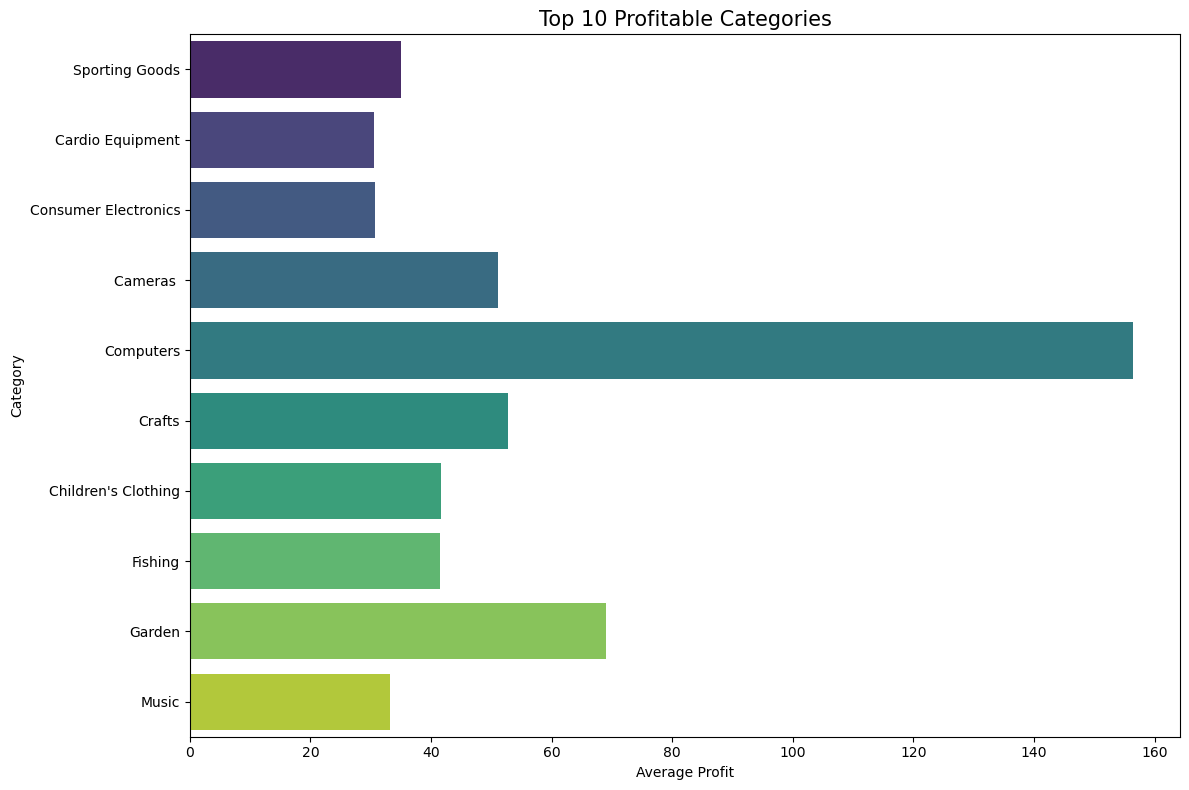

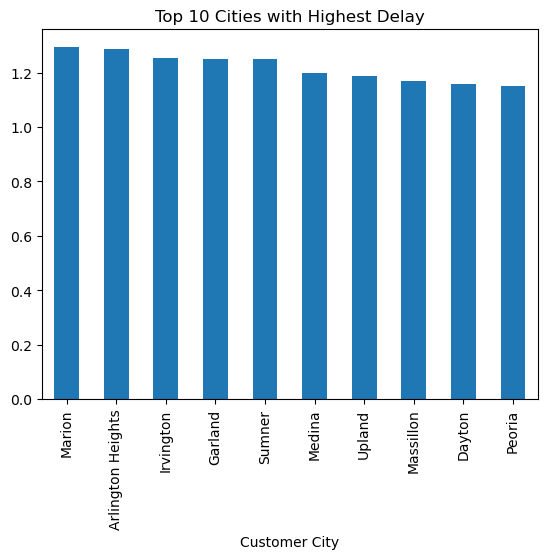

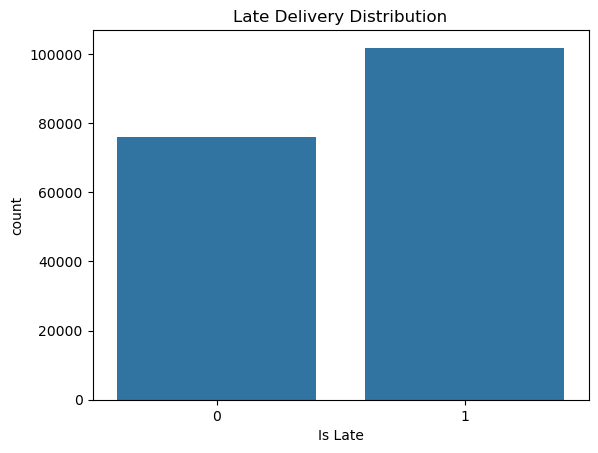

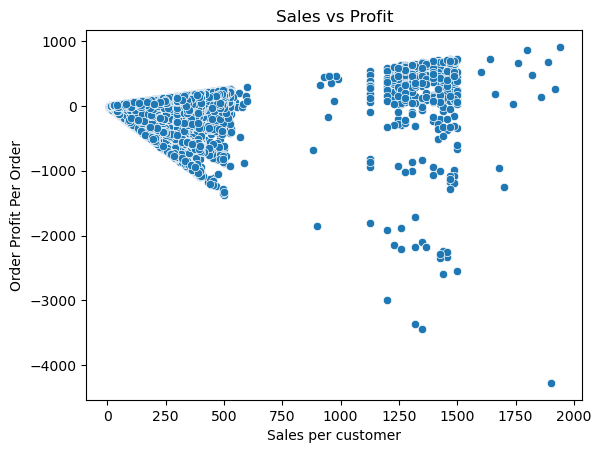

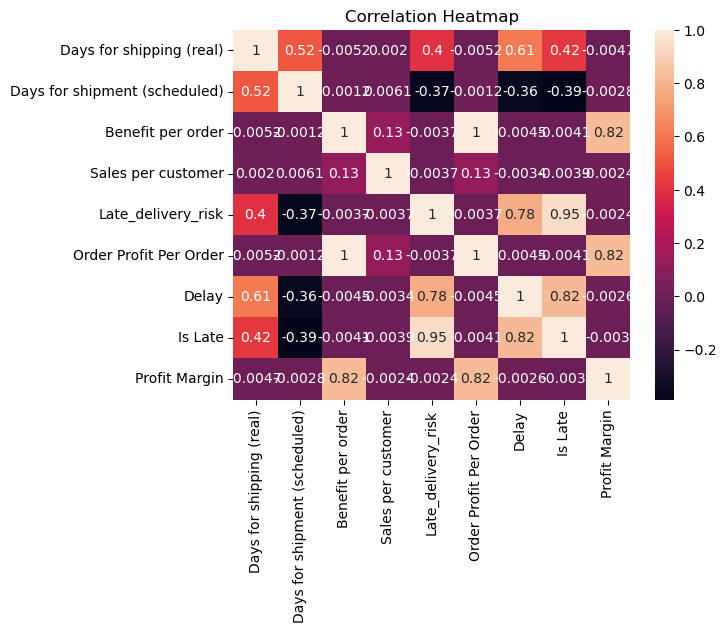

In [5]:
# 7. EDA (EXPLORATORY DATA ANALYSIS)
# ------------------------
# 7.1 Shipping Mode Analysis
# ------------------------
plt.figure()
sns.barplot(x='Shipping Mode', y='Delay', data=df)
plt.title('Shipping Mode vs Delay')
plt.xticks(rotation=45)
plt.show()

# ------------------------
# 7.2 Category vs Profit
# ------------------------
# 1. First, calculate top 10 categories to avoid the mess
top_10_categories = df.groupby('Category Name')['Order Profit Per Order'].mean().sort_values(ascending=False).head(10).index

# 2. Filter the dataframe for only these top 10
df_top10 = df[df['Category Name'].isin(top_10_categories)]

# 3. Create the Plot
plt.figure(figsize=(12, 8)) # Give it more space
sns.barplot(x='Order Profit Per Order', y='Category Name', data=df_top10, errorbar=None, hue='Category Name', palette='viridis')
plt.title('Top 10 Profitable Categories', fontsize=15)
plt.xlabel('Average Profit')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# ------------------------
# 7.3 City-wise Delay
# ------------------------
top_cities = df.groupby('Customer City')['Delay'].mean().sort_values(ascending=False).head(10)
plt.figure()
top_cities.plot(kind='bar')
plt.title('Top 10 Cities with Highest Delay')
plt.show()

# ------------------------
# 7.4 Late Delivery Count
# ------------------------
plt.figure()
sns.countplot(x='Is Late', data=df)
plt.title('Late Delivery Distribution')
plt.show()

# ------------------------
# 7.5 Profit vs Sales
# ------------------------
plt.figure()
sns.scatterplot(x='Sales per customer', y='Order Profit Per Order', data=df)
plt.title('Sales vs Profit')
plt.show()

# ------------------------
# 7.6 Correlation Heatmap
# ------------------------
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [13]:
# 8. BUSINESS INSIGHTS 
# ================================

print("\n--- BUSINESS INSIGHTS ---")

# Avg Delay
print("Average Delay:", df['Delay'].mean())

# Late Delivery %
late_percent = (df['Is Late'].sum() / len(df)) * 100
print("Late Delivery %:", late_percent)

# Best Category
best_category = df.groupby('Category Name')['Order Profit Per Order'].mean().idxmax()
print("Most Profitable Category:", best_category)

# Worst City (Highest Delay)
worst_city = df.groupby('Customer City')['Delay'].mean().idxmax()
print("City with Highest Delay:", worst_city)


--- BUSINESS INSIGHTS ---
Average Delay: 0.5687377635753988
Late Delivery %: 57.306411323896754
Most Profitable Category: Computers
City with Highest Delay: Marion


In [6]:
# 9. SAVE CLEAN DATA
# ================================
df.to_csv("supply_chain_dataset.csv", index=False)
print("\n✅  Best strategy: Allocate more resources to shipping modes with higher values.")


✅  Best strategy: Allocate more resources to shipping modes with higher values.


In [7]:
# ================================
# 10. OPTIMIZATION MODEL
# ================================

from scipy.optimize import linprog

# Average profit and delay per shipping mode
grouped = df.groupby('Shipping Mode').agg({
    'Order Profit Per Order': 'mean',
    'Delay': 'mean'
})

profits = grouped['Order Profit Per Order'].values
delays = grouped['Delay'].values

# Objective: maximize profit - delay penalty
# linprog minimizes → so we use negative
c = -(profits - 0.5 * delays)

# Constraints: total allocation <= 1
A = [np.ones(len(profits))]
b = [1]

# bounds (0 to 1 allocation)
x_bounds = [(0,1) for _ in range(len(profits))]

result = linprog(c, A_ub=A, b_ub=b, bounds=x_bounds)

# Output
print("\n===== OPTIMIZATION RESULT =====")

for i, mode in enumerate(grouped.index):
    print(f"{mode}: {result.x[i]:.2f}")

print("\n✅ Project Completed Successfully")


===== OPTIMIZATION RESULT =====
First Class: 1.00
Same Day: 0.00
Second Class: 0.00
Standard Class: -0.00

✅ Project Completed Successfully


## SQL-Scenario: Step 1

In [42]:
import sqlite3
import pandas as pd

#1. Connect to a database 
conn = sqlite3.connect('amazon_logistics.db')

print("Reading Excel file.... Please wait (this might take 2-3 minutes)")

#2. Load your excel data into Python
# replace 'supply_chain_dataset.xlsx' with your actual filename
df = pd.read_excel('supply_chain_dataset.xlsx', engine='openpyxl')
print(f"excel Loaded! Total rows: {len(df)}")

#3. Push the data into a SQL Table
df.to_sql('supply_chain_table', conn, if_exists='replace', index=False)

print("Status: Excel data successfully migrated into SQL database!")

Reading Excel file.... Please wait (this might take 2-3 minutes)
excel Loaded! Total rows: 180519
Status: Excel data successfully migrated into SQL database!


## Step-2: "The Late Delivery Challenge"

--- Business Insight: Late Delivery Rate by Mode ---
    Shipping Mode  total_orders  late_orders  late_rate_percentage
0     First Class         27814        26513                 95.32
1    Second Class         35216        26987                 76.63
2        Same Day          9737         4454                 45.74
3  Standard Class        107752        41023                 38.07


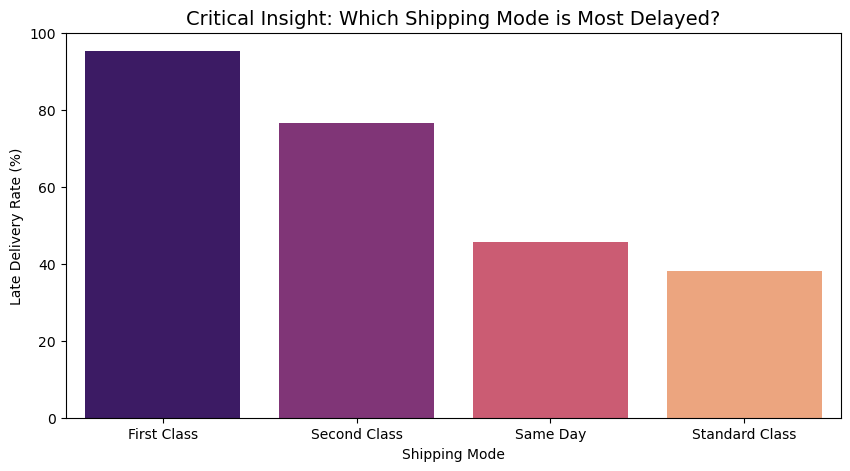

In [50]:
# SQL Query to calculate late delivery counts and rates

query = """
SELECT 
    "Shipping Mode", 
    COUNT(*) AS total_orders,
    SUM(CASE WHEN "Delivery Status" = 'Late delivery' THEN 1 ELSE 0 END) AS late_orders,
    ROUND(CAST(SUM(CASE WHEN "Delivery Status" = 'Late delivery' THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*) * 100, 2) AS late_rate_percentage
FROM supply_chain_table
GROUP BY "Shipping Mode"
ORDER BY late_rate_percentage DESC;
"""

# Execute SQL and get the result in a DataFrame
analysis_df = pd.read_sql_query(query, conn)

print("--- Business Insight: Late Delivery Rate by Mode ---")
print(analysis_df)

# --- STEP 3: VISUALIZE THE FINDINGS ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x='Shipping Mode', y='late_rate_percentage', data=analysis_df, hue='Shipping Mode', palette='magma')
plt.title('Critical Insight: Which Shipping Mode is Most Delayed?', fontsize=14)
plt.ylabel('Late Delivery Rate (%)')
plt.show()

## Step-3: Profit Loss ANALYSIS for Late Deliveries

In [1]:
print(loss_df.columns)

NameError: name 'loss_df' is not defined

In [56]:
# SQL Query to find categories losing the most profit during late deliveries
loss_query = """
SELECT 
    "Category Name", 
    SUM("Benefit per order") AS Total_Profit_Loss
FROM supply_chain_table
WHERE "Delivery Status" = 'Late delivery'
GROUP BY "Category Name"
ORDER BY Total_Profit_Loss ASC  -- ASC because we want to see the most negative (loss) first
LIMIT 10;
"""

loss_df = pd.read_sql_query(loss_query, conn)

print("--- Business Critical: Top Categories with Profit Issues (Late Deliveries) ---")
print(loss_df)

# --- VISUALIZATION ---
plt.figure(figsize=(12,6))
sns.barplot(x='Total_Profit_Loss', y='Category Name', data=loss_df, palette='viridis')
plt.title('Profit Impact: Categories with Lowest Benefit in Late Deliveries', fontsize=14)
plt.xlabel('Total Profit/Loss ($)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

--- Business Critical: Top Categories with Profit Issues (Late Deliveries) ---
  '"Category Name"'  Total_Profit_Loss
0   "Category Name"       2.140052e+06


ValueError: Could not interpret value `Category Name` for `y`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

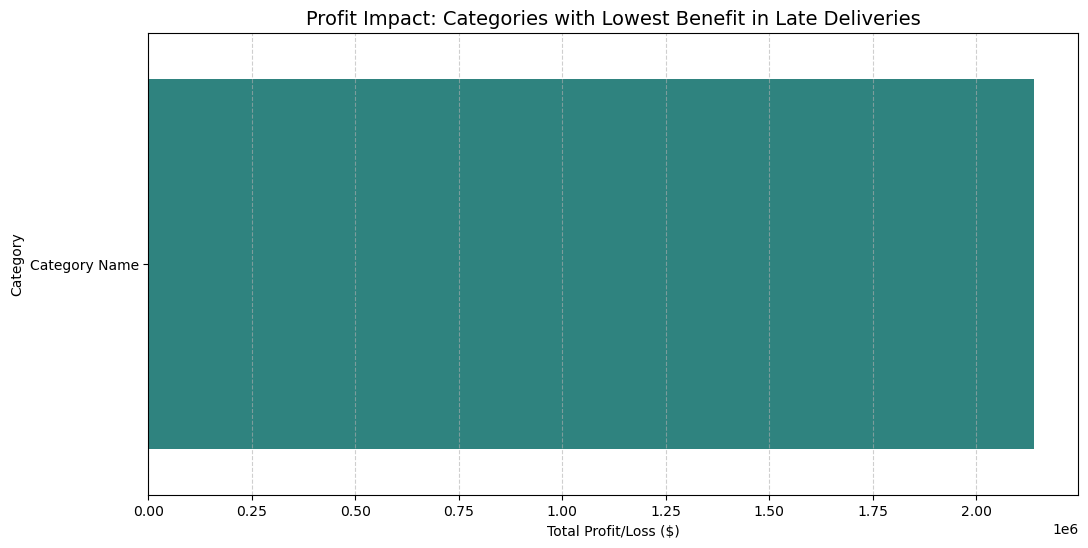

In [57]:
# --- corrected Step 3 CODE ---

# We give "Category Name" a clean alias called Category
loss_query = """
SELECT 
    "Category Name" AS Category, 
    SUM("Benefit per order") AS Total_Profit_Loss
FROM supply_chain_table
WHERE "Delivery Status" = 'Late delivery'
GROUP BY "Category Name"
ORDER BY Total_Profit_Loss ASC
LIMIT 10;
"""

loss_df = pd.read_sql_query(loss_query, conn)

# Now Python will see the column name as 'Category' (no quotes, no spaces)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(
    x='Total_Profit_Loss', 
    y='Category',             # Use the clean Alias name here
    data=loss_df, 
    palette='viridis',
    hue='Category', 
    legend=False
)

plt.title('Profit Impact: Categories with Lowest Benefit in Late Deliveries', fontsize=14)
plt.xlabel('Total Profit/Loss ($)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

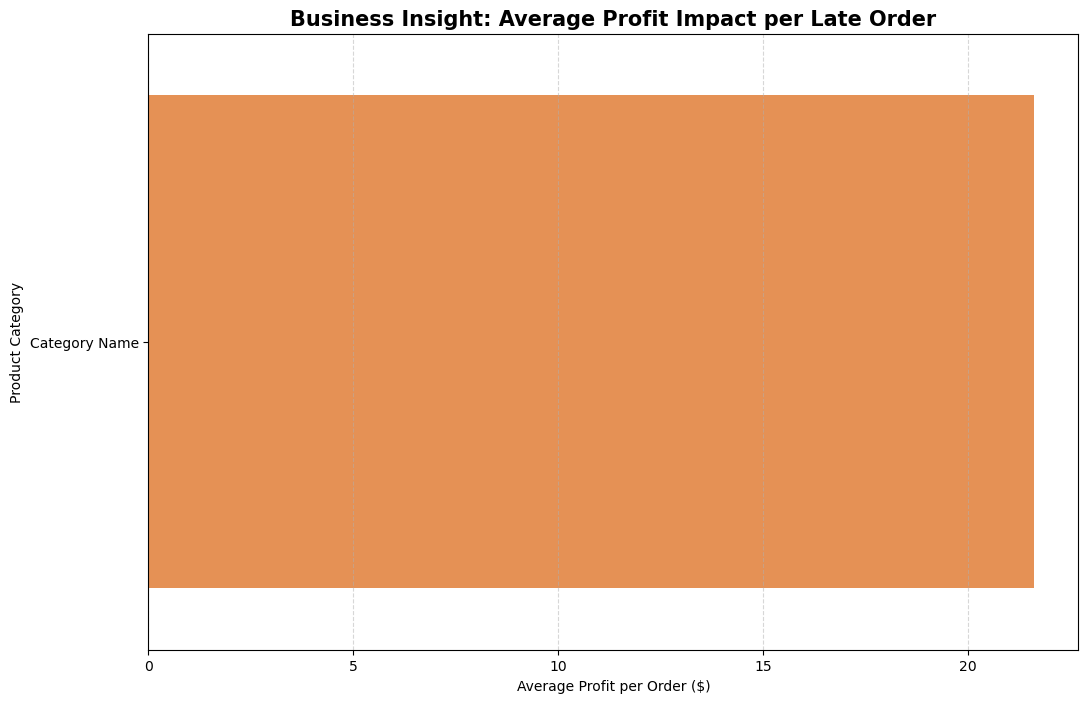

In [78]:
# --- IMPROVED ANALYSIS: AVG PROFIT PER LATE DELIVERY ---

query_v2 = """
SELECT 
    "Category Name" AS Category, 
    AVG("Benefit per order") AS Avg_Profit_per_Order
FROM supply_chain_table
WHERE "Delivery Status" = 'Late delivery'
GROUP BY 1
ORDER BY Avg_Profit_per_Order ASC -- Sabse kam profit upar dikhega
LIMIT 10;
"""

clean_df = pd.read_sql_query(query_v2, conn)

import seaborn as sns
import matplotlib.pyplot as plt

# Fig size bada kiya taaki categories saaf dikhen
plt.figure(figsize=(12, 8)) 

sns.barplot(
    x='Avg_Profit_per_Order', 
    y='Category', 
    data=clean_df, 
    palette='Oranges_r', # Dark orange to light orange
    hue='Category',
    legend=False
)

plt.title('Business Insight: Average Profit Impact per Late Order', fontsize=15, fontweight='bold')
plt.xlabel('Average Profit per Order ($)')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

## Step-4: Top  5 cities with Highest Profit Loss (Late deliveries)

--- Actionable Insight: Top 5 Loss-Making Cities ---
        City   Total_Loss
0    Pulheim -3456.150022
1  Cerignola -2822.939997
2     Luanda -2680.539953
3     Dudley -2225.300004
4    Seville -2006.820063


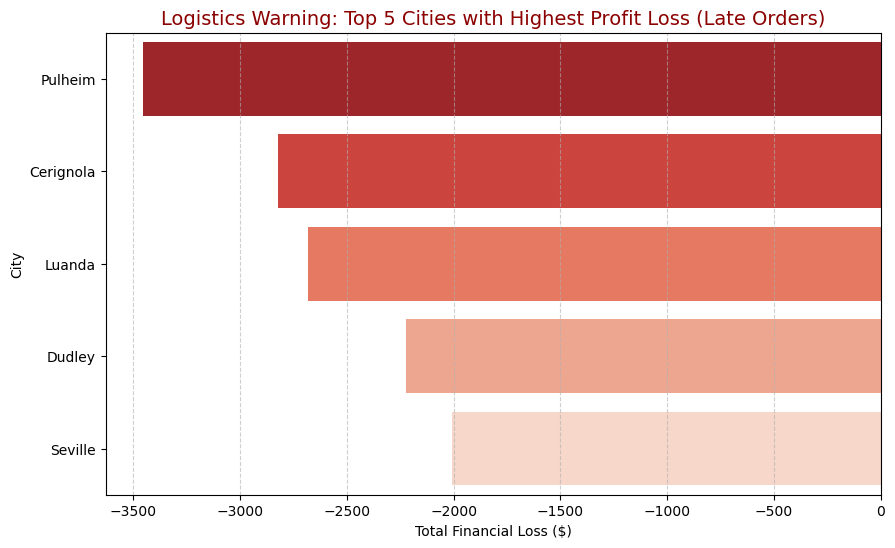

In [75]:
city_loss_query = """
SELECT 
    "Order City" AS City, 
    SUM("Benefit per order") AS Total_Loss
FROM supply_chain_table
WHERE "Delivery Status" = 'Late delivery'
GROUP BY 1
ORDER BY Total_Loss ASC  -- Ascending order to see the most negative (Loss) first
LIMIT 5;
"""

city_loss_df = pd.read_sql_query(city_loss_query, conn)

print("--- Actionable Insight: Top 5 Loss-Making Cities ---")
print(city_loss_df)

# Visualizing with a "Danger" (Red) color scheme
plt.figure(figsize=(10,6))
sns.barplot(
    x='Total_Loss', 
    y='City', 
    data=city_loss_df, 
    palette='Reds_r', # Dark Red to Light Red
    hue='City',
    legend=False
)

plt.title('Logistics Warning: Top 5 Cities with Highest Profit Loss (Late Orders)', fontsize=14, color='darkred')
plt.xlabel('Total Financial Loss ($)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

## Step-5: Correlation between Scheduled vs Real shipping days

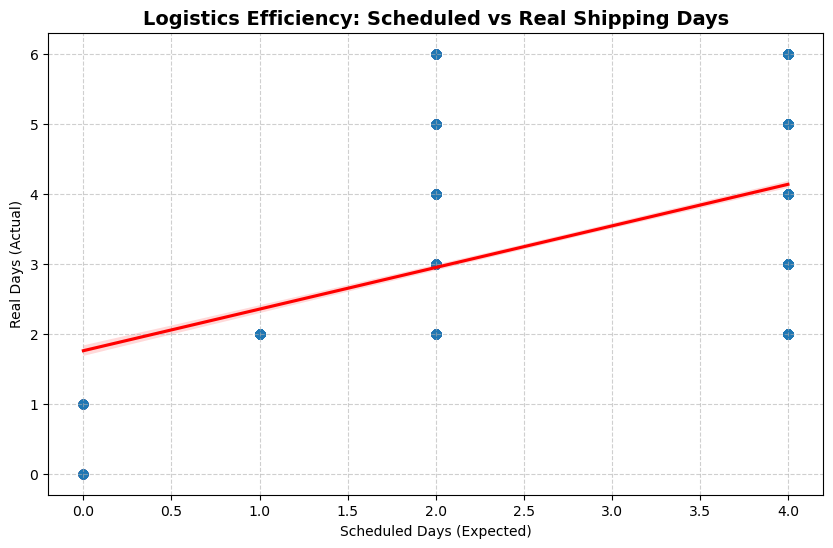

In [80]:
query_scatter = """
SELECT 
    "Days for shipment (scheduled)" AS Scheduled,
    "Days for shipping (real)" AS Real
FROM supply_chain_table
LIMIT 5000; -- Checking 5000 samples for speed
"""

scatter_df = pd.read_sql_query(query_scatter, conn)

plt.figure(figsize=(10, 6))
# Adding a regression line to see the trend
sns.regplot(x='Scheduled', y='Real', data=scatter_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Logistics Efficiency: Scheduled vs Real Shipping Days', fontsize=14, fontweight='bold')
plt.xlabel('Scheduled Days (Expected)')
plt.ylabel('Real Days (Actual)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [81]:
# FINAL STEP: THE BUSINESS SUMMARY DASHBOARD 

summary_query = """
SELECT 
    "Shipping Mode",
    COUNT(*) AS Total_Orders,
    ROUND(AVG("Days for shipping (real)"), 2) AS Avg_Actual_Days,
    SUM(CASE WHEN "Delivery Status" = 'Late delivery' THEN 1 ELSE 0 END) AS Total_Late_Orders,
    ROUND(CAST(SUM(CASE WHEN "Delivery Status" = 'Late delivery' THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*) * 100, 2) AS Delay_Rate_Percentage,
    ROUND(SUM("Benefit per order"), 2) AS Net_Benefit
FROM supply_chain_table
GROUP BY 1
ORDER BY Net_Benefit DESC;
"""

final_summary_df = pd.read_sql_query(summary_query, conn)

print("==============================================================")
print("             AMAZON FREIGHT: PERFORMANCE SUMMARY              ")
print("==============================================================")
print(final_summary_df)
print("==============================================================")

             AMAZON FREIGHT: PERFORMANCE SUMMARY              
    Shipping Mode  Total_Orders  Avg_Actual_Days  Total_Late_Orders  \
0  Standard Class        107752             4.00              41023   
1    Second Class         35216             3.99              26987   
2     First Class         27814             2.00              26513   
3        Same Day          9737             0.48               4454   

   Delay_Rate_Percentage  Net_Benefit  
0                  38.07   2370454.45  
1                  76.63    750308.17  
2                  95.32    643121.92  
3                  45.74    203018.43  
